# Problem 6
***

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statistics


In [2]:
# Define the ticker. For each of the tickers I add the corresponding names.

tickers = {
    'AAPL': 'Apple',
    'AAL': 'American airlines',
    'TSLA': 'Tesla',
    'GC=F': 'Gold',
    'CL=F': 'Crude oil',
    # Also adding equinor last  .
    'EQNR.OL': 'Equinor'
}

# Defining the start and end date for the data.
start_date = '2013-01-01'
end_date = '2023-01-01'

# Download historical data. Using a for loop that goes through all tickers, with start as start_date and end as end_date given. The ['Adj Close'] only gives the 
# Adjusted close column with the correct index.
data = {}
for ticker, name in tickers.items():
    data[name] = yf.download(ticker, start=start_date, end=end_date, ignore_tz=True, progress=False)['Adj Close'] 

data = pd.DataFrame(data)

In [3]:
log_returns = np.log(data / data.shift(1))
mean_log_ret = log_returns.tail(252).mean()
cov_matrix = log_returns.tail(252).cov()

c:\ProgramData\Anaconda3\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [4]:

num_portfolios = 10000
results = np.zeros((3,num_portfolios))
weights = np.zeros(6)

for i in list(range(num_portfolios)):

    equinor_weight = i/num_portfolios
    weights[:4] = (1-equinor_weight)/(len(tickers)-1)
    weights[5] = equinor_weight
    portfolio_return = np.sum(mean_log_ret* weights)*252
    portfolio_std_dev = np.sqrt(np.dot(weights,np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Sharpe Ratio
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    # Dont need to include the risk free rate because it does not change the largest answer.
    results[2,i] = (results[0,i] ) / results[1,i]

results_frame = pd.DataFrame(results.T,columns=['return','stdev','sharpe'])

In [5]:
#locate position of portfolio with highest Sharpe Ratio
max_sharpe_port_ = {}
max_sharpe_port_ = results_frame['sharpe'].idxmax()

display(max_sharpe_port_)


9999

##### By these numbers we can see that the name/index 9999 is the largest sharpe ratio which tells us that it has the highest risk-return rate. If you use this number in the for loop created, we can see that this is when the equinor weight is equal to 1. (Equinor weight is i/num_portfolios, which is the number of iteration - 1 divided by the total of iterations. This means the number of iteration is 10000 and i/10000=1) This also means that the share of the other assets are zero. 

In [8]:
# Creating a for loop that goes through the length of log_returns - 252 (To get all the rolling dates we have available). Dividing the
# weights we check for equinor in 200, because the iteration takes a long time. Could go a lot smaller (more iterations) for better answer. 
max_sharpe_port = {}
for n in list(range(len(log_returns)-252)):
    mean_log_ret = log_returns[n:252+n].mean()
    cov_matrix = log_returns[n:252+n].cov()

    num_portfolios = 200
    results = np.zeros((3,num_portfolios))
    weights = np.zeros(6)

    for i in list(range(num_portfolios)):

        equinor_weight = i/num_portfolios
        weights[:4] = (1-equinor_weight)/(len(tickers)-1)
        weights[5] = equinor_weight
        portfolio_return = np.sum(mean_log_ret* weights)*252
        portfolio_std_dev = np.sqrt(np.dot(weights,np.dot(cov_matrix, weights))) * np.sqrt(252)

        # Sharpe Ratio
        results[0,i] = portfolio_return
        results[1,i] = portfolio_std_dev
        # Dont need to include the risk free rate because it does not change the largest answer.
        results[2,i] = (results[0,i] ) / results[1,i]

        results_frame = pd.DataFrame(results.T,columns=['return','stdev','sharpe'])
        #locate position of portfolio with highest Sharpe Ratio
    max_sharpe_port[int(n)] = results_frame['sharpe'].idxmax()



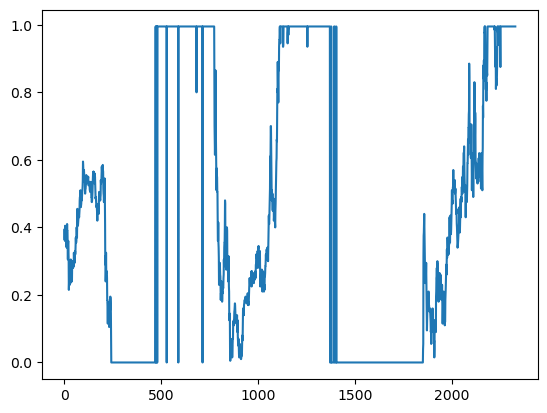

In [14]:
max = pd.DataFrame(max_sharpe_port,index=[0])
max = max.transpose()

plt.plot(max/num_portfolios)

##### Here we can see the weight of Equinor stock at which the highest sharpe ratio is, depending on which market day we are at after 252 days after 1-1-2013. At 0 we have the first 252 values of 2013 and calculating the sharpe ratio based on its standard deviation and mean. We can see that it goes a lot up and down and the last values are around 1, which we already calculated earlier in the problem. 